# Feature sifting on a clean-or-noise problem

**Problem.** `phd/jax_core/tasks/clean_or_noise_sifting.py` is a variant of
`phd/jax_core/tasks/feature_sifting.py` that changes one thing: a drawn candidate feature is
either an **exact copy** of one of the target's signals (with probability `CLEAN_PROB`) or an
**independent uniform draw** over the same range. Nothing sits in between. The target sums
`N_TARGET_FEATURES` signals, each uniform on $[-1, 1]$ with a weight of $\pm 1$, under $N(0, 1)$
observation noise, and the learner observes `N_LEARNER_FEATURES` candidate slots.

Where the original task offers a *continuum* of partial views that a method can climb, quality
here is binary, and the two kinds of candidate share the same marginal distribution — so a slot
cannot be judged from its own values at all, only from how its weight moves. Because a copy is
exact, a learner that covers every signal reaches the irreducible MSE of 1.0 exactly. The MSE
therefore measures the search, which is the question here: how well does a pruning rule find the
few real features in a pool of noise?

**Learner.** One linear predictor over the slots, plus a bias, every weight starting at zero.
Every slot is always connected and always carries a value, so the only structural decision is
which slots to throw away. Pruning a slot does not free a weight — it **redraws the feature behind
it**, and resets the slot to its starting state (zero weight, `INIT_STEP_SIZE`, no traces).

**Methods.** LMS at a fixed step-size and plain Autostep never prune, and show what the initial
pool is worth. The three pruning rules are generate & test (cut a slot the step its weight crosses
zero), the same plus a subgradient L1 penalty, and a band test (cut a slot whose weight is inside
the noise band of a dead slot of the same age).

The last two exist because the bare zero-crossing test stalls at small step-sizes: the pull that
returns a dead weight to zero relaxes over $1/(\alpha\,\mathbb{E}[x^2])$ steps, so below that
horizon the weight is a nearly driftless walk that may never cross back and never be tested. L1
*drives* the weight to zero instead of waiting for it, at a drift-to-noise ratio $\lambda/\sigma$
that is $\alpha$-free; the band drops the crossing requirement altogether, comparing the weight
against the width a dead weight of the same age would have wandered, which is $\alpha$-free too.

In [1]:
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import seaborn as sns

from phd.jax_core.optimizers.idbd import optax_idbd, IDBDState
from phd.jax_core.tasks.clean_or_noise_sifting import CleanOrNoiseSiftingTask
from phd.jax_core.utils import stack_pytrees, tree_replace
from phd.research_utils.analysis.analysis_utils import get_color_palette

sns.set_theme('notebook', 'white')
%matplotlib inline

In [2]:
# --- Problem ---
N_TARGET_FEATURES = 10               # true signals the target function sums
N_LEARNER_FEATURES = 10              # candidate slots the learner observes
CLEAN_PROB = 0.01                    # chance a drawn candidate is an exact copy of a signal
SAMPLING = {                         # each rule is run and plotted separately
    False: 'without replacement',
    # True: 'with replacement',
}
NOISE_STD = 1.0                      # observation noise on the target
INPUT_BOUNDS = (-1.0, 1.0)           # uniform range, shared by the signals and the distractors

# --- Optimizers ---
LMS_STEP_SIZE = 0.001
INIT_STEP_SIZE = 1e-10               # Autostep's starting step-size for every slot
META_STEP_SIZE = 0.02
L1_COEFF = 0.01                      # subgradient L1 on the candidate weights (method 4)
BAND_TRACE_HORIZON = 1_000           # EMA horizon for E[delta^2] (method 5)

# --- Training and recording ---
NUM_STEPS = 200_000
N_SEEDS = 30                         # vmapped into one scan; scan width is nearly free
N_SNAPSHOTS = 200                    # recording points per run
BASE_SEED = 0

# --- Derived ---
N_OUTPUTS = 1                        # one target, but the (output, slot) grid shape is kept
N_SLOTS = N_LEARNER_FEATURES + 1     # one weight per candidate, plus a bias column
INPUT_VAR = (INPUT_BOUNDS[1] - INPUT_BOUNDS[0]) ** 2 / 12   # variance of any one feature
IRREDUCIBLE_MSE = NOISE_STD ** 2                            # MSE with every signal covered


def max_clean(with_replacement):
    """Most slots that can hold a real signal at once under the given sampling rule.

    Without replacement the signals are handed out one to a slot, so the pool cannot hold more
    clean slots than the target function has signals.
    """
    if with_replacement:
        return N_LEARNER_FEATURES
    return min(N_LEARNER_FEATURES, N_TARGET_FEATURES)

## Learners

Each method is a self-contained `eqx.Module` with `init()` and `step(inputs, y)`, and carries the
`prune_mask` the task reads to redraw candidates. `inputs` is the `(n_outputs, n_learner_features)`
slot grid, padded here with the bias column. Keeping the `n_outputs` axis around with a single
output costs nothing and keeps the code identical to the multi-output version of this notebook.

In [3]:
def slot_inputs(inputs):
    """Pad the slot grid with the bias column: a constant-1 input, never a candidate.

    Keeping the bias inside the weight matrix is what Autostep's per-output-row normalizer
    needs — it does not support a separate bias vector.
    """
    return jnp.concatenate([inputs, jnp.ones((N_OUTPUTS, 1))], axis=1)


def linear_loss_and_grads(w, x, y):
    """Squared error, and the LMS gradient `delta * x`.

    That is the exact gradient up to the constant factor 2, which is folded into the step-size.
    """
    error = jnp.sum(w * x, axis=-1) - y
    return jnp.sum(error ** 2), error[:, None] * x


def init_autostep(cls, **extra):
    """Build an Autostep-based learner: zero weights, a fresh optimizer state, nothing pruned."""
    optimizer = optax_idbd(init_lr=INIT_STEP_SIZE, meta_lr=META_STEP_SIZE, autostep=True)
    w = jnp.zeros((N_OUTPUTS, N_SLOTS))
    return cls(optimizer=optimizer, w=w, opt_state=optimizer.init(w),
               prune_mask=jnp.zeros((N_OUTPUTS, N_LEARNER_FEATURES), dtype=bool), **extra)


def reset_pruned(w, opt_state, prune_mask):
    """Return every slot the learner just cut to its starting state: zero weight, `INIT_STEP_SIZE`,
    no traces.

    The slot index never changes here — only the feature behind it does — so this reset is what
    makes a fresh candidate start with no inherited history. It is applied on the step the slot is
    cut, and the task swaps the new candidate in at the top of the next one.
    """
    pruned = jnp.pad(prune_mask, ((0, 0), (0, 1)))     # the bias column is never pruned
    return jnp.where(pruned, 0.0, w), IDBDState(
        init_beta=opt_state.init_beta,
        beta=jnp.where(pruned, opt_state.init_beta, opt_state.beta),
        h=jnp.where(pruned, 0.0, opt_state.h),
        v=jnp.where(pruned, 0.0, opt_state.v),
    )

In [4]:
class LMS(eqx.Module):
    """Least mean squares at a fixed step-size on the initial pool; never prunes."""
    w: jax.Array
    prune_mask: jax.Array

    @classmethod
    def init(cls):
        return cls(w=jnp.zeros((N_OUTPUTS, N_SLOTS)),
                   prune_mask=jnp.zeros((N_OUTPUTS, N_LEARNER_FEATURES), dtype=bool))

    def step(self, inputs, y):
        x = slot_inputs(inputs)
        loss, grads = linear_loss_and_grads(self.w, x, y)
        # prune_mask stays all-False
        return tree_replace(self, w=self.w - LMS_STEP_SIZE * grads), loss

In [5]:
class Autostep(eqx.Module):
    """Autostep (IDBD) on the initial pool: a step-size per slot, but no pruning."""
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    prune_mask: jax.Array

    @classmethod
    def init(cls):
        return init_autostep(cls)

    def step(self, inputs, y):
        x = slot_inputs(inputs)
        loss, grads = linear_loss_and_grads(self.w, x, y)
        # Autostep consumes the loss gradient and the prediction gradient (= x, this being a
        # linear model), and normalizes each output's row of step-sizes on its own.
        updates, opt_state = self.optimizer.update((grads, x), self.opt_state, self.w)
        return tree_replace(self, w=self.w + updates, opt_state=opt_state), loss

In [6]:
class AutostepGT(eqx.Module):
    """Autostep + generate & test: a slot is cut the step its weight crosses zero.

    The task redraws every cut slot, so the learner keeps the same weights and trades away the
    ones a real gradient is no longer holding off zero — for a replacement that is an exact copy
    of a true signal only `CLEAN_PROB` of the time, and pure noise otherwise. A cut slot is reset
    to `w = 0` (`reset_pruned`), so the product below is zero on the new candidate's first step
    and it is never cut on arrival.

    With `l1 > 0` the subgradient `lambda * sign(w)` joins the loss gradient, so it drives the
    weight update *and* Autostep's step-size adaptation. Its contribution to a step is
    `alpha * lambda` against gradient noise `alpha * sigma`, so the ratio is step-size free: a
    dead weight is actively driven back across zero instead of waiting on a mean reversion whose
    rate vanishes with `alpha`. That is what keeps the cut firing at any `INIT_STEP_SIZE`, which
    the bare test does not. The bias against a true weight of magnitude 1 is `L1_COEFF / E[x^2]`
    = 0.03, so the penalty costs the fit little while doing its work on the dead slots.
    """
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    l1: float = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    prune_mask: jax.Array

    @classmethod
    def init(cls, l1=0.0):
        return init_autostep(cls, l1=l1)

    def step(self, inputs, y):
        x = slot_inputs(inputs)
        loss, grads = linear_loss_and_grads(self.w, x, y)
        if self.l1:
            # L1 on the candidates only: shrinking the bias fights the target's mean, not
            # structure. `loss` stays pure squared error, so the MSE curves stay comparable.
            grads = grads + self.l1 * jnp.sign(self.w).at[:, -1].set(0.0)
        updates, opt_state = self.optimizer.update((grads, x), self.opt_state, self.w)
        w = self.w + updates

        # The bias column is not a candidate, so it is sliced back off the mask.
        prune_mask = (self.w * w < 0.0)[:, :N_LEARNER_FEATURES]
        w, opt_state = reset_pruned(w, opt_state, prune_mask)
        return tree_replace(self, w=w, opt_state=opt_state, prune_mask=prune_mask), loss

In [7]:
class AutostepBand(eqx.Module):
    """Autostep + band pruning: a slot is cut once its weight is inside the noise band of a dead
    slot **of the same age**.

    A dead slot's weight is a mean-reverting random walk whose stationary one-sigma band is
    `s = sqrt(alpha * E[delta^2] / 2)` (derived in
    `phd/sandbox/feature_sifting/exploration/lasso_step_size_protection_algo.ipynb`), with
    `E[delta^2]` the *plain* squared residual of the output. `E[x^2]` cancels out of `s`, so a
    feature's scale does not enter.

    The stationary band is useless on its own: every new candidate is born at `w = 0`, deep inside
    it, so the test would cut every candidate on arrival and the pool would never settle. What the
    rule needs is the band for a weight of the slot's own age,

        s(t) = s * sqrt(m_t),    m_t = 1 - rho^t,    rho = E[(1 - alpha x^2)^2]

    which starts at zero alongside the weight and widens at exactly the rate a dead weight
    wanders, while a useful weight's mean grows linearly and clears it after about
    `9 E[delta^2] / (w*^2 E[x^2])` steps. `alpha` cancels there, so the test keeps firing at any
    step-size — which is what the bare zero-crossing test fails to do, and why no L1 is needed
    here. With `w* = 1` and `E[x^2] = 1/3` that is a few hundred steps at the start of a run.

    The maturity is accumulated as `log(1 - m_t)` rather than as `m_t` itself, because the direct
    form cancels catastrophically in float32: once `alpha E[x^2]` drops below `eps / 2 ~ 6e-8`,
    `1 - alpha x^2` rounds to exactly 1 and the trace freezes at zero. A zero maturity is a
    zero-width band, so nothing is ever prunable and the method silently degenerates to plain
    Autostep. The log form is accurate down to ~1e-13.

    The weight is tested against the maturity it had *before* this step's update, so a candidate
    on its first step meets a zero-width band and always survives it.
    """
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    v: jax.Array          # (n_outputs, 1) EMA of the output's squared residual
    v_weight: jax.Array   # accumulated EMA gain, so `v` reads unbiased from step 1
    log_imm: jax.Array    # (n_outputs, n_slots) log(1 - maturity): 0 at birth, -inf once mature
    prune_mask: jax.Array

    @classmethod
    def init(cls):
        return init_autostep(cls, v=jnp.zeros((N_OUTPUTS, 1)), v_weight=jnp.zeros(()),
                             log_imm=jnp.zeros((N_OUTPUTS, N_SLOTS)))

    def step(self, inputs, y):
        x = slot_inputs(inputs)
        # `linear_loss_and_grads` reduces the squared error over outputs; the band needs the
        # residual itself, so the two lines are spelled out here instead.
        error = jnp.sum(self.w * x, axis=-1) - y
        loss, grads = jnp.sum(error ** 2), error[:, None] * x
        updates, opt_state = self.optimizer.update((grads, x), self.opt_state, self.w)
        w = self.w + updates

        # E[delta^2] belongs to the output's residual, not to any one slot, so a redraw leaves it
        # alone; `v_weight` de-biases it away from its zero start.
        gain = 1.0 / BAND_TRACE_HORIZON
        v = self.v + gain * (error[:, None] ** 2 - self.v)
        v_weight = self.v_weight + gain * (1.0 - self.v_weight)

        # The band the *pre-update* weight age calls for, then the age advances.
        alpha = jnp.exp(opt_state.beta)
        band = jnp.sqrt(alpha * (v / v_weight) / 2.0 * -jnp.expm1(self.log_imm))
        log_imm = self.log_imm + 2.0 * jnp.log1p(-alpha * x ** 2)

        prune_mask = (jnp.abs(w) < band)[:, :N_LEARNER_FEATURES]
        w, opt_state = reset_pruned(w, opt_state, prune_mask)
        # A redrawn slot restarts its warm-up, so it meets a zero-width band on its first step.
        log_imm = jnp.where(jnp.pad(prune_mask, ((0, 0), (0, 1))), 0.0, log_imm)
        return tree_replace(self, w=w, opt_state=opt_state, v=v, v_weight=v_weight,
                            log_imm=log_imm, prune_mask=prune_mask), loss

## Training

In [8]:
def make_task(seed, with_replacement):
    return CleanOrNoiseSiftingTask(
        n_target_features=N_TARGET_FEATURES, n_learner_features=N_LEARNER_FEATURES,
        clean_prob=CLEAN_PROB, with_replacement=with_replacement,
        target_noise_std=NOISE_STD, input_bounds=INPUT_BOUNDS,
        key=jax.random.PRNGKey(seed))


def train(learner, task, block_len):
    """Online training in `N_SNAPSHOTS` blocks of `block_len` steps, one summary row per block."""
    def one_step(carry, _):
        learner, task = carry
        # The task is single-output and speaks in flat slot vectors; the learner keeps the
        # (output, slot) grid shape, so the two meet with one row.
        task, (inputs, y) = task.step(learner.prune_mask[0])   # the task redraws what was cut
        learner, loss = learner.step(inputs[None, :], y)
        return (learner, task), (loss, jnp.sum(learner.prune_mask))

    def block(carry, _):
        carry, (losses, n_cut) = jax.lax.scan(one_step, carry, length=block_len)
        task = carry[1]
        return carry, (losses.mean(), n_cut.mean(),
                       jnp.mean(task.is_clean.astype(jnp.float32)),
                       task.covered.astype(jnp.float32))

    _, out = jax.lax.scan(block, (learner, task), length=N_SNAPSHOTS)
    return out


def run(make_learner, with_replacement, task_fn=make_task, num_steps=NUM_STEPS):
    """Train `N_SEEDS` independent runs — a fresh teacher and pool each — in one vmapped scan."""
    block_len = num_steps // N_SNAPSHOTS
    tasks = stack_pytrees([task_fn(BASE_SEED + s, with_replacement) for s in range(N_SEEDS)])
    keys = ('mse', 'cut_rate', 'clean', 'covered')
    out = jax.jit(jax.vmap(lambda task: train(make_learner(), task, block_len)))(tasks)
    return {'steps': np.arange(1, N_SNAPSHOTS + 1) * block_len,
            **{k: np.asarray(v) for k, v in zip(keys, out)}}


def run_all(with_replacement, task_fn=make_task, num_steps=NUM_STEPS):
    """Every method on one sampling rule. `with_replacement` is static, so each rule compiles
    its own scan; the seeds are shared, so the two rules see the same teachers."""
    l1_gt = lambda: AutostepGT.init(l1=L1_COEFF)
    return {
        f'LMS (step-size {LMS_STEP_SIZE:g})': run(LMS.init, with_replacement, task_fn, num_steps),
        'Autostep': run(Autostep.init, with_replacement, task_fn, num_steps),
        'Autostep + G&T': run(AutostepGT.init, with_replacement, task_fn, num_steps),
        f'Autostep + L1 {L1_COEFF:g} + G&T': run(l1_gt, with_replacement, task_fn, num_steps),
        'Autostep + band': run(AutostepBand.init, with_replacement, task_fn, num_steps),
    }


runs = {with_replacement: run_all(with_replacement) for with_replacement in SAMPLING}

## Results

Coverage is what caps a method: every signal it has no copy of leaves its own variance $1/3$ in
the residual. The dotted line beside each learning curve is that floor for the coverage the method
actually reached, so the gap between a solid curve and its own dotted one is what the method's
*weights* got wrong, separated from what its *search* never found.

The two pool panels are worth reading together. Without replacement they carry the same
information on two scales — no copy is ever redundant, so the number of clean slots and the number
of distinct signals covered are the same number. With replacement they come apart, and the gap
between them is exactly the slots lost to duplicates.

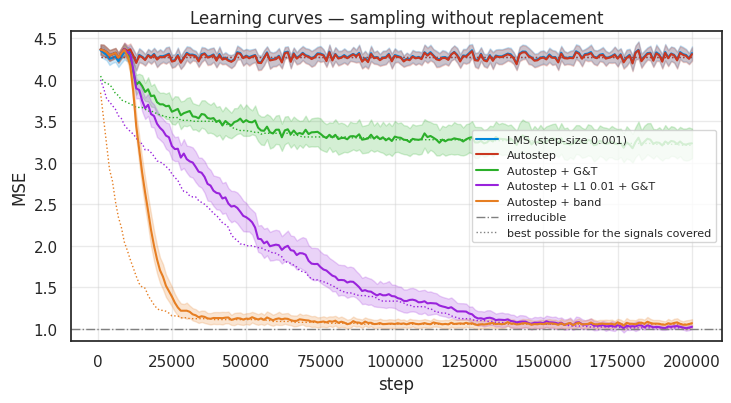

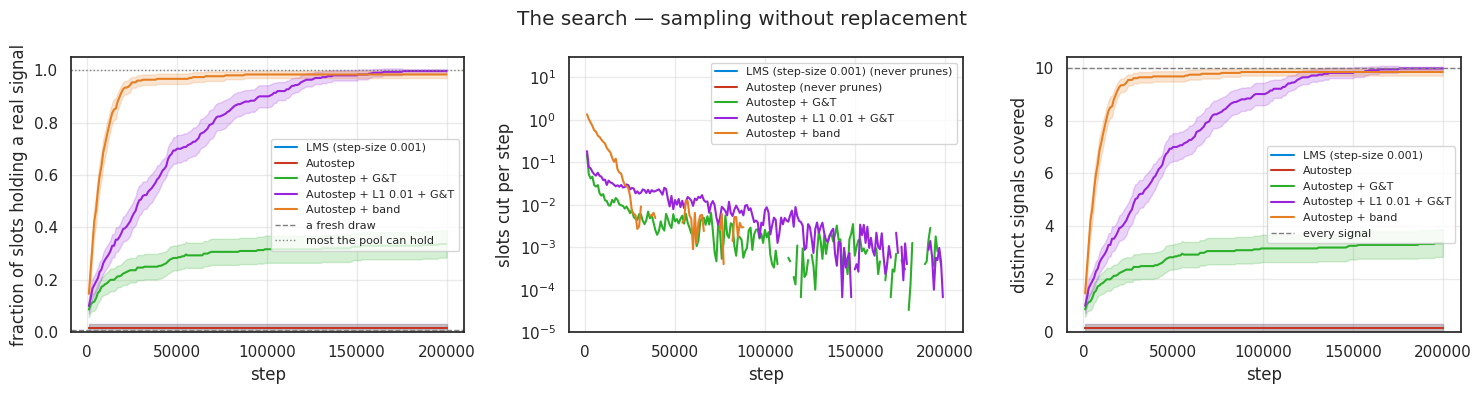

In [9]:
def plot_curves(methods, with_replacement, target_w2=np.ones(N_TARGET_FEATURES)):
    """MSE per method, mean +- 2 standard errors over seeds, against the floor set by the signals
    each method has actually covered (dotted, in the method's own color).

    `target_w2` holds the square of each signal's weight in the target, which is what leaving that
    signal uncovered costs.
    """
    baseline = IRREDUCIBLE_MSE + target_w2.sum() * INPUT_VAR   # the mean predictor: none covered
    plt.figure(figsize=(7.5, 4.2))
    for (label, res), color in zip(methods.items(), get_color_palette(n=len(methods))):
        mean = res['mse'].mean(0)
        sem = res['mse'].std(0) / np.sqrt(N_SEEDS)
        plt.plot(res['steps'], mean, color=color, label=label)
        plt.fill_between(res['steps'], mean - 2 * sem, mean + 2 * sem, color=color, alpha=0.2)
        # Every signal the method has no copy of leaves its own variance in the residual.
        floor = IRREDUCIBLE_MSE + ((1 - res['covered']) * target_w2).sum(-1) * INPUT_VAR
        plt.plot(res['steps'], floor.mean(0), color=color, ls=':', lw=1)
    plt.axhline(IRREDUCIBLE_MSE, ls='-.', c='gray', lw=1, label='irreducible')
    plt.plot([], [], c='gray', ls=':', lw=1, label='best possible for the signals covered')
    plt.xlabel('step')
    plt.ylabel('MSE')
    # Both rules share the axes, so the two figures can be read against each other directly.
    plt.ylim(0.85, baseline + 0.25)
    plt.title(f'Learning curves — sampling {SAMPLING[with_replacement]}')
    plt.grid(alpha=0.4)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_search(methods, with_replacement):
    """What the sifting does: how much of the pool is real signal, how fast it churns, and how
    many distinct signals it has found a copy of."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for (label, res), color in zip(methods.items(), get_color_palette(n=len(methods))):
        for ax, series in ((axes[0], res['clean']), (axes[2], res['covered'].sum(-1))):
            mean = series.mean(0)
            sem = series.std(0) / np.sqrt(N_SEEDS)
            ax.plot(res['steps'], mean, color=color, label=label)
            ax.fill_between(res['steps'], mean - 2 * sem, mean + 2 * sem, color=color, alpha=0.2)

        rate = res['cut_rate'].mean(0)
        if np.any(rate > 0):
            axes[1].plot(res['steps'], np.where(rate > 0, rate, np.nan), color=color, label=label)
        else:
            axes[1].plot([], [], color=color, label=f'{label} (never prunes)')

    axes[0].axhline(CLEAN_PROB, ls='--', c='gray', lw=1, label='a fresh draw')
    axes[0].axhline(max_clean(with_replacement) / N_LEARNER_FEATURES, ls=':', c='gray', lw=1,
                    label='most the pool can hold')
    axes[0].set_ylabel('fraction of slots holding a real signal')
    axes[0].set_ylim(0, 1.05)
    axes[1].set_ylabel('slots cut per step')
    axes[1].set_yscale('log')
    axes[1].set_ylim(1e-5, 30)
    axes[2].axhline(N_TARGET_FEATURES, ls='--', c='gray', lw=1, label='every signal')
    axes[2].set_ylabel('distinct signals covered')
    axes[2].set_ylim(0, N_TARGET_FEATURES + 0.4)
    for ax in axes:
        ax.set_xlabel('step')
        ax.grid(alpha=0.4)
        ax.legend(fontsize=8)
    fig.suptitle(f'The search — sampling {SAMPLING[with_replacement]}')
    fig.tight_layout()
    plt.show()


for with_replacement, methods in runs.items():
    plot_curves(methods, with_replacement)
    plot_search(methods, with_replacement)

**Pruning is the whole game.** At `CLEAN_PROB` = 1% the initial pool holds essentially no signal,
so LMS and Autostep never move off 4.33 for the entire run. All three pruning rules do better, but
they are far apart, and the middle panel says why.

- **Autostep + G&T** stalls at ~3.3 of the 10 signals and an MSE of ~3.25, its cut rate decaying
  by two orders of magnitude over the run. This is the stall the other two variants exist for: at
  a small step-size a distractor's weight wanders as an almost driftless walk, because the pull
  back toward zero scales with the weight magnitude while the walk does not, so it takes ever
  longer to cross and be tested.
- **Autostep + L1 + G&T** cuts several times more often throughout and covers every signal by
  ~170k. The penalty keeps pushing on weights the loss is indifferent to, so the test keeps firing.
- **Autostep + band** covers every signal by ~30k, five times faster, and then stops cutting
  entirely. It never waits for a crossing, so it recognizes a dead weight within a few steps of
  its birth; and with as many slots as signals and no replacement, a full pool leaves it nothing
  left to redraw.

The dotted coverage floors run ahead of the solid curves — most visibly for L1, which needs
another ~50k steps to fit signals it has already found — but the ordering is set by the search,
not by the fitting.

## Signals with small ideal weights

Step-size adaptation is meant to sort out signals of differing utility on its own. An L1 penalty
is not: a lasso weight only stays off zero if its unpenalized value clears the penalty, which in
weight units is `L1_COEFF / E[x^2]` = 0.03 here. Any signal the target leans on less than that
should be driven across zero and cut, however real it is. The band test has no such constant in
it, but it is not free either — a weight of size $w^*$ needs about
$9\,\mathbb{E}[\delta^2] / (w^{*2}\,\mathbb{E}[x^2])$ steps to climb out of the band once drawn,
which is 30k steps at $w^* = 0.03$ and 7M at $w^* = 0.002$ — so small signals should get slow
rather than impossible.

To test both, the target weights become $\pm 2^{-i}$ instead of $\pm 1$: the first signal is worth
1, the second 0.5, down to $2^{-9} \approx 0.002$ for the tenth. Nothing else about the task
changes, except that the run is twenty-five times longer, since small signals are slow either
way.

The MSE says much less here. A missing $2^{-9}$ signal costs $4^{-9}/3 \approx 10^{-6}$, so the
mean predictor sits at 1.44 rather than 4.33 and nearly all of that gap is the first two signals.
Which signals a method ends up holding is the readout, and the last figure is that.

In [ ]:
TARGET_WEIGHTS = 2.0 ** -np.arange(N_TARGET_FEATURES)   # 1, 1/2, 1/4, ..., ~0.002
L1_THRESHOLD = L1_COEFF / INPUT_VAR                     # the smallest weight L1 leaves standing
DECAY_NUM_STEPS = 2_000_000                             # a much longer run: small signals are slow


def make_decaying_task(seed, with_replacement):
    """The same task with the target's unit weights scaled by `TARGET_WEIGHTS`, signs kept."""
    task = make_task(seed, with_replacement)
    return tree_replace(task, weights=task.weights * TARGET_WEIGHTS)


decaying_runs = {wr: run_all(wr, make_decaying_task, DECAY_NUM_STEPS) for wr in SAMPLING}

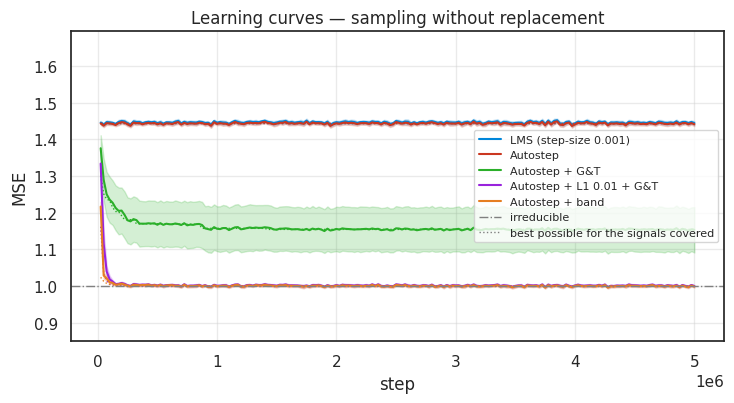

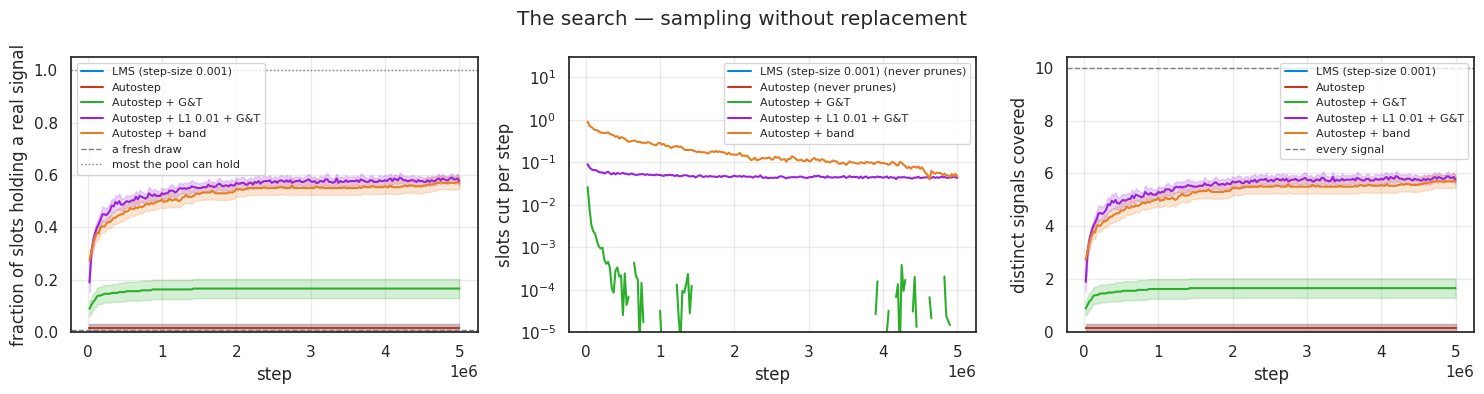

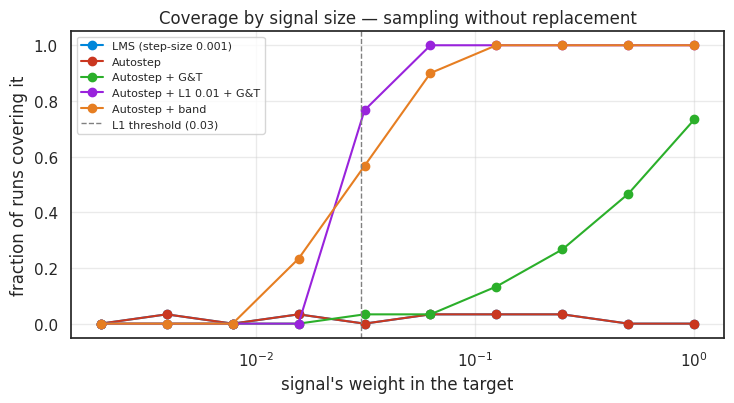

In [11]:
def plot_signal_coverage(methods, with_replacement):
    """Which signals survive: how often each one is covered at the end of training, by its weight."""
    plt.figure(figsize=(7.5, 4.2))
    for (label, res), color in zip(methods.items(), get_color_palette(n=len(methods))):
        plt.plot(TARGET_WEIGHTS, res['covered'][:, -1].mean(0), 'o-', color=color, label=label)
    plt.axvline(L1_THRESHOLD, ls='--', c='gray', lw=1, label=f'L1 threshold ({L1_THRESHOLD:g})')
    plt.xscale('log')
    plt.xlabel("signal's weight in the target")
    plt.ylabel('fraction of runs covering it')
    plt.ylim(-0.05, 1.05)
    plt.title(f'Coverage by signal size — sampling {SAMPLING[with_replacement]}')
    plt.grid(alpha=0.4)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


for with_replacement, methods in decaying_runs.items():
    plot_curves(methods, with_replacement, TARGET_WEIGHTS ** 2)
    plot_search(methods, with_replacement)
    plot_signal_coverage(methods, with_replacement)

**The L1 threshold is real, and it sits exactly where the algebra puts it.** `Autostep + L1 + G&T`
covers every signal down to $2^{-4} = 0.0625$ in all 30 runs, holds the one at $2^{-5} = 0.031$ — the
penalty's own threshold — in 77% of them, and covers *nothing at all* below it: 0 of 30 runs at every
smaller weight, unchanged from 2M steps onward. That is a floor rather than a rate. A signal the target
leans on less than `L1_COEFF / E[x^2]` is worth nothing to the penalized objective, so its weight is driven
back across zero and the slot recycled, however real the signal is. The threshold is $\lambda /
\mathbb{E}[x^2] = 0.03$, three times $\lambda$ itself, so the cutoff lands at the sixth signal rather than
the eighth.

**The band has no floor, only a slowing.** `Autostep + band` rolls off gradually instead of falling off a
cliff — 90% at $2^{-4}$, 57% at $2^{-5}$, and 23% at $2^{-6} = 0.0156$, which is *below* the L1 threshold and
where L1 is flat zero. Its curve is still rising at 5M (coverage of $2^{-6}$ goes 0.10, 0.13, 0.17, 0.17,
0.23 across the run) and it is still cutting at 0.046 slots/step. A small signal is not rejected here; it
needs longer to clear the band than the run allows, and that clearing time
$\approx 9\,\mathbb{E}[\delta^2] / (w^{*2}\,\mathbb{E}[x^2])$ quadruples with every halving of $w^*$.

**Plain G&T is worse here than with unit weights**, at 1.67 signals and frozen — its cut rate is zero by 1M
and its coverage has not moved since. Small weights make the zero-crossing stall harder to escape, not
easier.

**MSE hides all of it.** L1 and the band both land at the irreducible 1.0 within noise, because the signals
still in dispute are the ones the target barely uses: leaving all four of the smallest uncovered costs about
$10^{-4}$. The coverage figure is where the difference lives.

The two limits are different in kind, and that is the useful result. L1's is a property of the objective
that no amount of extra time will move. The band's is a property of the horizon — it accumulates evidence,
just slowly, and slowly in a way that is quadratic in $1/w^*$.